In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import gymnasium as gym

np.random.seed(42)
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

## Problem 1(c)
### Policy: stick if sum ≥ 20, otherwise hit. Run 500,000 episodes.

In [2]:
def fixed_policy(observation):
    player_sum, _, _ = observation
    return 0 if player_sum >= 20 else 1 


def first_visit_mc_prediction(policy, env, num_episodes=500000):
    V = defaultdict(float)
    returns_count = defaultdict(int)

    for _ in range(num_episodes):
        episode = []
        state, _ = env.reset()
        done = False

        while not done:
            action = policy(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode.append((state, reward))
            state = next_state
            done = terminated or truncated

        G = 0
        visited = set()
        for t in reversed(range(len(episode))):
            s_t, r_tp1 = episode[t]
            G = G + r_tp1  
            if s_t not in visited:
                visited.add(s_t)
                returns_count[s_t] += 1
                V[s_t] += (G - V[s_t]) / returns_count[s_t]

    return V

In [3]:
env = gym.make('Blackjack-v1', sab=True)
V = first_visit_mc_prediction(fixed_policy, env, num_episodes=500000)
print(f"Estimated values for {len(V)} states.")

Estimated values for 280 states.


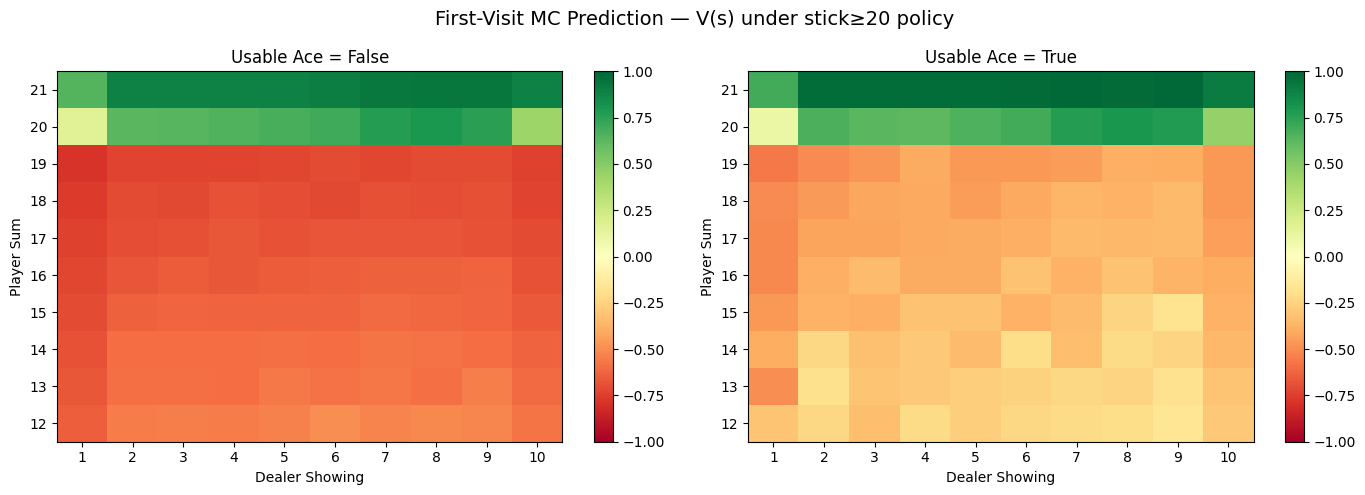

In [4]:
def plot_value_function(V, title="State-Value Function"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax_idx, usable_ace in enumerate([False, True]):
        player_range = range(12, 22)
        dealer_range = range(1, 11)
        grid = np.zeros((len(player_range), len(dealer_range)))

        for i, p in enumerate(player_range):
            for j, d in enumerate(dealer_range):
                grid[i, j] = V.get((p, d, usable_ace), 0)

        im = axes[ax_idx].imshow(
            grid, cmap='RdYlGn', origin='lower',
            extent=[0.5, 10.5, 11.5, 21.5], aspect='auto',
            vmin=-1, vmax=1
        )
        axes[ax_idx].set_xlabel('Dealer Showing')
        axes[ax_idx].set_ylabel('Player Sum')
        axes[ax_idx].set_title(f'Usable Ace = {usable_ace}')
        axes[ax_idx].set_xticks(range(1, 11))
        axes[ax_idx].set_yticks(range(12, 22))
        plt.colorbar(im, ax=axes[ax_idx])

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig('1c_mc_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_value_function(V, title='First-Visit MC Prediction — V(s) under stick≥20 policy')


## Problem 1(d)
### $ε = 0.1$, estimate $q_*$. Run 500,000 episodes.

In [5]:
def mc_control_epsilon_soft(env, num_episodes=500000, epsilon=0.1, gamma=1.0):
    Q = defaultdict(lambda: np.zeros(2)) 
    returns_count = defaultdict(lambda: np.zeros(2))

    def epsilon_greedy(state):
        if np.random.random() < epsilon:
            return np.random.randint(2)
        return int(np.argmax(Q[state]))

    for _ in range(num_episodes):
        episode = []
        state, _ = env.reset()
        done = False

        while not done:
            action = epsilon_greedy(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            done = terminated or truncated

        G = 0
        visited = set()
        for t in reversed(range(len(episode))):
            s_t, a_t, r_tp1 = episode[t]
            G = gamma * G + r_tp1
            sa = (s_t, a_t)
            if sa not in visited:
                visited.add(sa)
                returns_count[s_t][a_t] += 1
                Q[s_t][a_t] += (G - Q[s_t][a_t]) / returns_count[s_t][a_t]

    policy = {}
    for state in Q:
        policy[state] = int(np.argmax(Q[state]))

    return Q, policy

In [6]:
env = gym.make('Blackjack-v1', sab=True)
Q, learned_policy = mc_control_epsilon_soft(env, num_episodes=500000)
print(f"Learned Q-values for {len(Q)} states.")

Learned Q-values for 280 states.


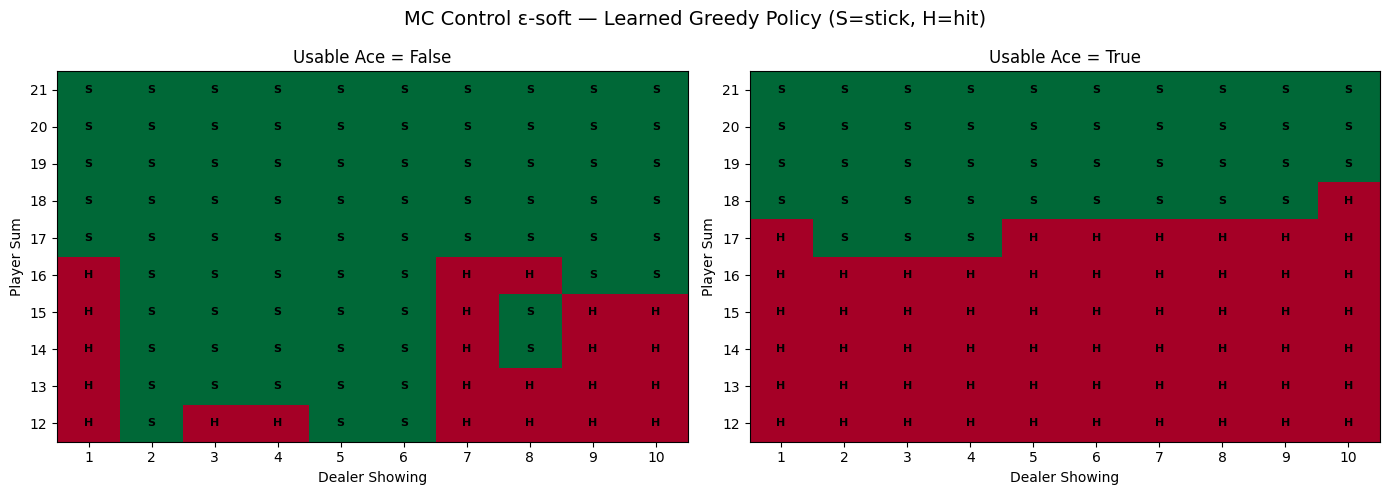

In [7]:
def plot_policy(policy, title="Learned Policy"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    action_labels = {0: 'S', 1: 'H'} 

    for ax_idx, usable_ace in enumerate([False, True]):
        player_range = range(12, 22)
        dealer_range = range(1, 11)
        grid = np.zeros((len(player_range), len(dealer_range)))

        for i, p in enumerate(player_range):
            for j, d in enumerate(dealer_range):
                grid[i, j] = policy.get((p, d, usable_ace), 0)

        im = axes[ax_idx].imshow(
            grid, cmap='RdYlGn_r', origin='lower',
            extent=[0.5, 10.5, 11.5, 21.5], aspect='auto',
            vmin=0, vmax=1
        )
        axes[ax_idx].set_xlabel('Dealer Showing')
        axes[ax_idx].set_ylabel('Player Sum')
        axes[ax_idx].set_title(f'Usable Ace = {usable_ace}')
        axes[ax_idx].set_xticks(range(1, 11))
        axes[ax_idx].set_yticks(range(12, 22))

        for i, p in enumerate(player_range):
            for j, d in enumerate(dealer_range):
                action = policy.get((p, d, usable_ace), 0)
                axes[ax_idx].text(d, p, action_labels[action],
                                  ha='center', va='center', fontsize=8,
                                  color='black', fontweight='bold')

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig('1d_mc_control_policy.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_policy(learned_policy, title='MC Control ε-soft — Learned Greedy Policy (S=stick, H=hit)')

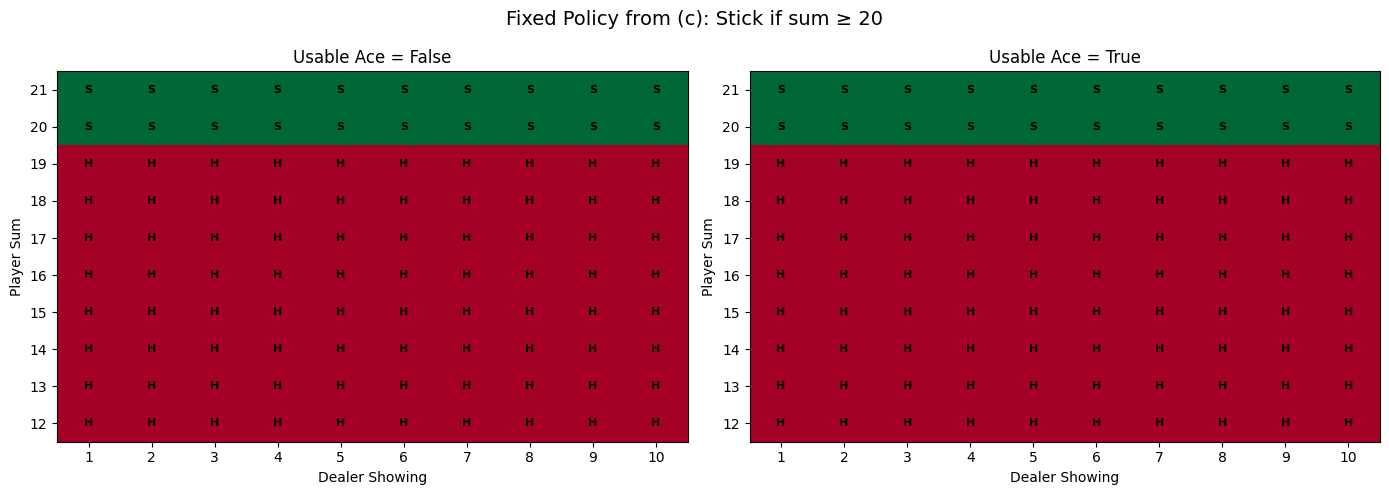

In [8]:
fixed = {}
for p in range(12, 22):
    for d in range(1, 11):
        for ace in [True, False]:
            fixed[(p, d, ace)] = 0 if p >= 20 else 1  # stick>=20

plot_policy(fixed, title='Fixed Policy from (c): Stick if sum ≥ 20')

**Comparison of learned policy vs. fixed policy:**

Fixed policy always hits on 12–19 and sticks on 20–21 regardless of the dealer's card.

The learned optimal policy differs in:
- **Without usable ace:** The learned policy sticks at lower sums, around 17–19, when the dealer shows a weak card, around 2–6, since the dealer is likely to bust. But it still hits on sums like 12–16 against strong dealer cards (7–10, Ace).
- **With usable ace:** The learned policy is more aggressive — it hits at higher sums (up to 17 or 18) because the usable ace provides a safety net, which can be counted as 1 instead of 11 if the player would bust.
- The main difference is the learned policy sticks earlier (around 17) against weak dealers, while the fixed policy always hits below 20.


---
## Problem 2(c)

- __States__: $A$($terminal$)$–B–C–D–E–F–G$($terminal$), start at $D$
- $R=+1$ for transitioning to $G$, $R=0$ otherwise, $γ=1.0$
- __True values__: $(1/6, 2/6, 3/6, 4/6, 5/6)$
- ___Run 100 episodes for each___

In [ ]:
class RandomWalkEnv:
    def __init__(self):
        self.n_states = 7  # indices, from 0 - 6, representing A - G 
        self.start_state = 3  # start at D
        self.state = self.start_state

    def reset(self):
        self.state = self.start_state
        return self.state

    def step(self):
        if np.random.random() < 0.5:
            self.state -= 1  
        else:
            self.state += 1  

        reward = 1.0 if self.state == 6 else 0.0
        done = (self.state == 0 or self.state == 6)
        return self.state, reward, done


TRUE_VALUES = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 0])  
STATE_NAMES = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [10]:
def td0_prediction(env, num_episodes=100, alpha=0.1, gamma=1.0):
    V = np.full(7, 0.5)
    V[0] = V[6] = 0.0  
    rms_history = []

    for ep in range(num_episodes):
        state = env.reset()
        done = False
        while not done:
            next_state, reward, done = env.step()
            V[state] += alpha * (reward + gamma * V[next_state] - V[state])
            state = next_state

        rms = np.sqrt(np.mean((V[1:6] - TRUE_VALUES[1:6])**2))
        rms_history.append(rms)

    return V, rms_history


def mc_prediction(env, num_episodes=100, alpha=0.01, gamma=1.0):
    V = np.full(7, 0.5)
    V[0] = V[6] = 0.0
    rms_history = []

    for ep in range(num_episodes):
        episode = []
        state = env.reset()
        done = False
        while not done:
            next_state, reward, done = env.step()
            episode.append((state, reward))
            state = next_state

        G = 0
        visited = set()
        for t in reversed(range(len(episode))):
            s_t, r_tp1 = episode[t]
            G = gamma * G + r_tp1
            if s_t not in visited:
                visited.add(s_t)
                V[s_t] += alpha * (G - V[s_t])

        rms = np.sqrt(np.mean((V[1:6] - TRUE_VALUES[1:6])**2))
        rms_history.append(rms)

    return V, rms_history

In [11]:
env = RandomWalkEnv()
V_td, rms_td = td0_prediction(env, num_episodes=100, alpha=0.1)

env = RandomWalkEnv()
V_mc, rms_mc = mc_prediction(env, num_episodes=100, alpha=0.01)

print("TD(0) final values (B-F):", np.round(V_td[1:6], 4))
print("MC final values (B-F):", np.round(V_mc[1:6], 4))
print("True values (B-F):", np.round(TRUE_VALUES[1:6], 4), '\n')
print('RMS (B-F) of TD(0):', np.round(rms_td, 4), '\n')
print('------------------------------------------------------------------------\n')
print('RMS (B-F) of MC:', np.round(rms_mc, 4))

TD(0) final values (B-F): [0.1405 0.4043 0.5632 0.6833 0.8308]
MC final values (B-F): [0.3475 0.4168 0.5054 0.5653 0.6481]
True values (B-F): [0.1667 0.3333 0.5    0.6667 0.8333] 

RMS (B-F) of TD(0): [0.2222 0.2079 0.1959 0.1829 0.1725 0.1628 0.1509 0.1421 0.1361 0.1334
 0.1189 0.1128 0.1124 0.0988 0.0853 0.0808 0.0695 0.0716 0.0697 0.0572
 0.0544 0.0537 0.0459 0.0599 0.0618 0.0687 0.0526 0.0373 0.0339 0.0387
 0.0391 0.0421 0.0426 0.0362 0.0284 0.0258 0.0305 0.0351 0.0376 0.0368
 0.0365 0.0406 0.0216 0.0303 0.041  0.0303 0.034  0.0435 0.0253 0.0314
 0.0421 0.035  0.0464 0.0507 0.0585 0.0675 0.0727 0.0824 0.0723 0.0837
 0.0714 0.0529 0.0644 0.0862 0.0673 0.0707 0.0551 0.0428 0.0326 0.0361
 0.0417 0.0507 0.0345 0.0365 0.0353 0.0392 0.047  0.0224 0.0318 0.0411
 0.0504 0.039  0.0288 0.0379 0.0333 0.033  0.0379 0.0475 0.0307 0.0348
 0.0332 0.0445 0.0321 0.0323 0.0341 0.0475 0.0371 0.0306 0.0395 0.0447] 

------------------------------------------------------------------------

RMS (B-F) of

---
## Problem 2(d)

- __TD__: $α ∈ {0.05, 0.1, 0.15} $
- __MC__: $α ∈ {0.01, 0.02, 0.04} $
- ___Averaged over 50 independent runs___

In [12]:
num_runs = 50
num_episodes = 100

td_alphas = [0.05, 0.1, 0.15]
mc_alphas = [0.01, 0.02, 0.04]

td_results = {a: np.zeros(num_episodes) for a in td_alphas}
mc_results = {a: np.zeros(num_episodes) for a in mc_alphas}

for run in range(num_runs):
    for alpha in td_alphas:
        env = RandomWalkEnv()
        _, rms = td0_prediction(env, num_episodes=num_episodes, alpha=alpha)
        td_results[alpha] += np.array(rms)

    for alpha in mc_alphas:
        env = RandomWalkEnv()
        _, rms = mc_prediction(env, num_episodes=num_episodes, alpha=alpha)
        mc_results[alpha] += np.array(rms)

for a in td_alphas:
    td_results[a] /= num_runs
for a in mc_alphas:
    mc_results[a] /= num_runs

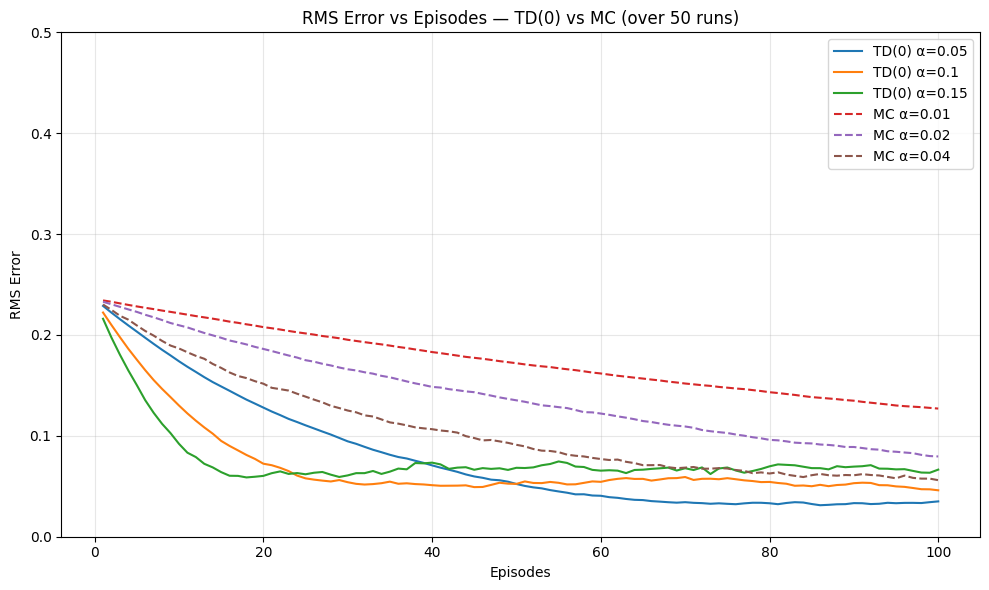

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

for alpha in td_alphas:
    ax.plot(range(1, num_episodes + 1), td_results[alpha],
            label=f'TD(0) α={alpha}', linestyle='-')

for alpha in mc_alphas:
    ax.plot(range(1, num_episodes + 1), mc_results[alpha],
            label=f'MC α={alpha}', linestyle='--')

ax.set_xlabel('Episodes')
ax.set_ylabel('RMS Error')
ax.set_title(f'RMS Error vs Episodes — TD(0) vs MC (over {num_runs} runs)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.show()

**Observations:**

- **TD(0) converges faster than MC across all tested step sizes.** Even with the smallest TD step size (α=0.05), TD(0) reaches lower RMS error within fewer episodes than MC with any step size. This is because TD(0) can learn from each individual transition while MC must wait until the end of each episode to update.

- **TD(0) step size sensitivity:** Larger α values (0.15) cause faster initial learning but may lead to oscillation. Moderate values (α=0.1) tend to give a good balance of speed and stability. 

- **MC step size sensitivity:** MC requires much smaller step sizes than TD on this task. α=0.04 for MC is the most aggressive learning rate, and it still converges more slowly than TD, because MC updates have higher variance from the full return.

- **Asymptotic performance:** Both methods converge toward zero error given enough episodes, but TD reaches faster. However, the constant-α versions never reach exactly zero error.